# 3. MINI-LABS (HIỂU TỪNG MODULE QUA VÍ DỤ NHỎ)

## 3.1 FPN – Feature Pyramid Network (trực quan hoá multi-scale)

--> Using device: cpu
    Running on CPU mode (PyTorch threads: 8)
Tìm thấy 4 ảnh trong thư mục: ../assets/images
Image: image copy 2.png


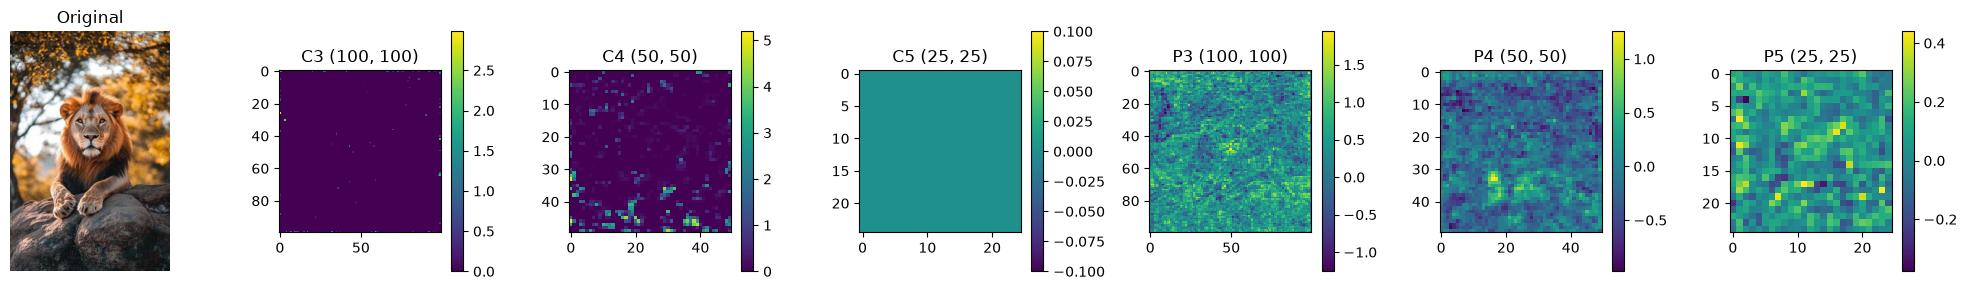

Image: image copy 3.png


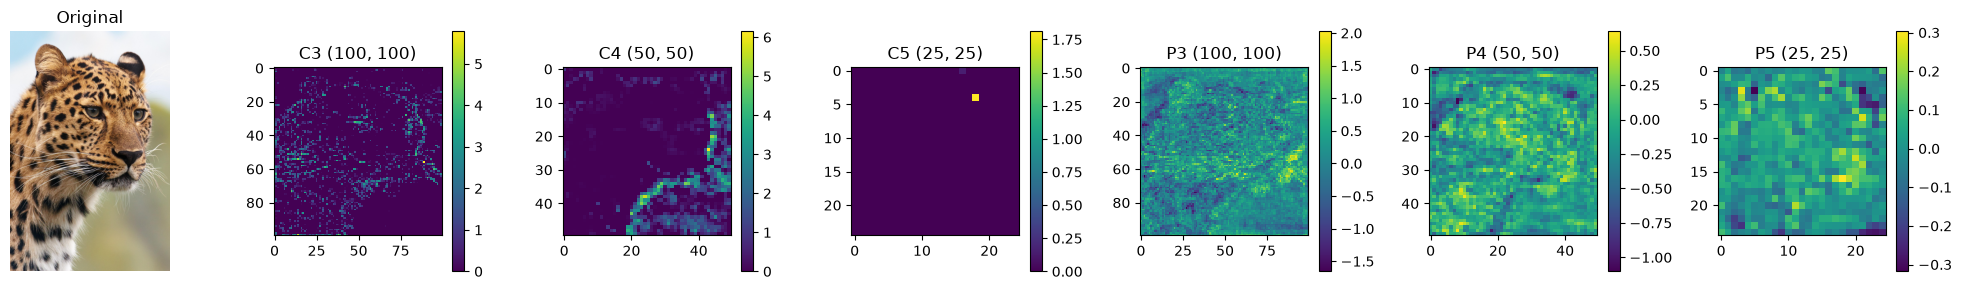

Image: image copy.png


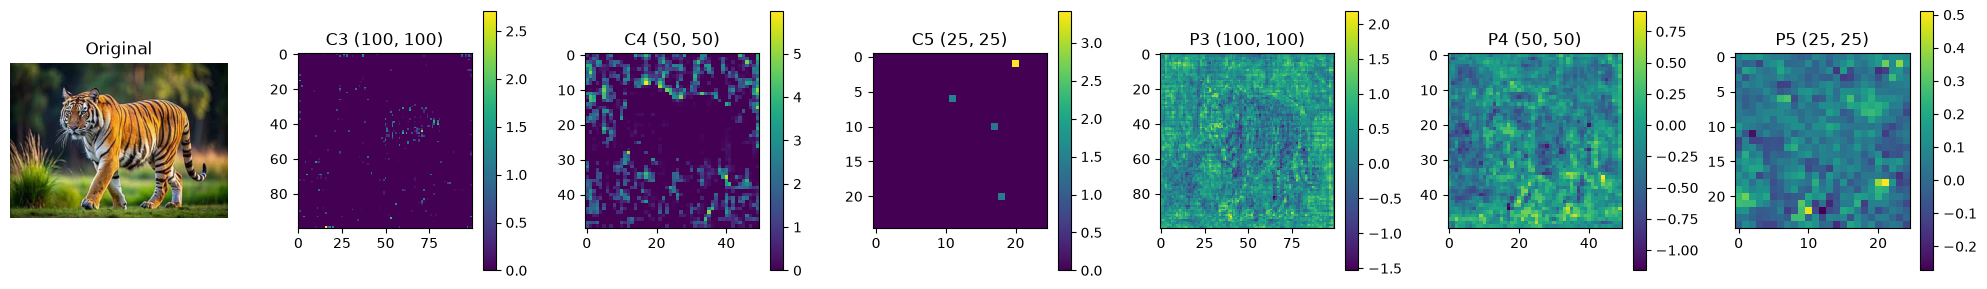

Image: image.png


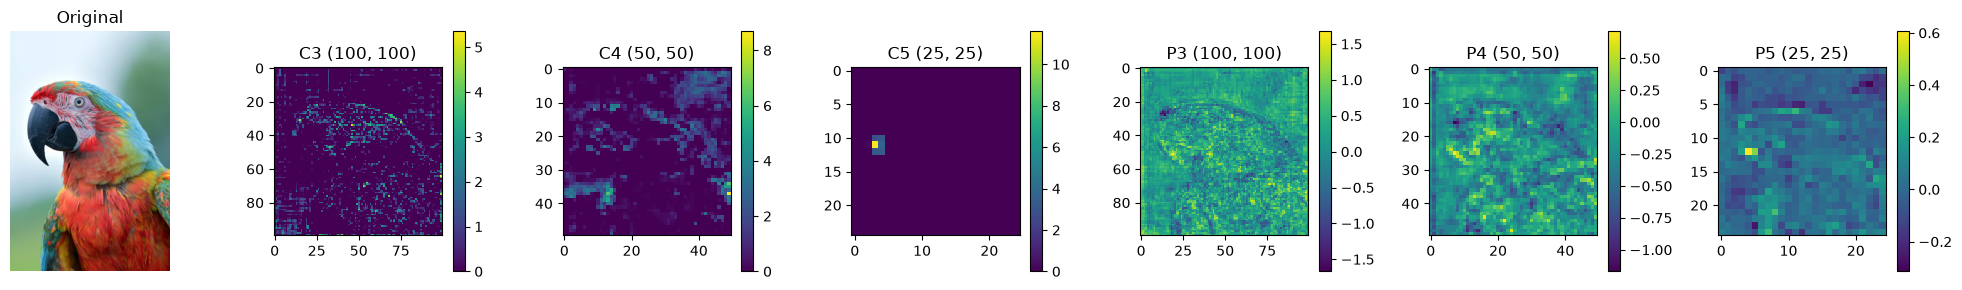

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision.models.feature_extraction import create_feature_extractor
from PIL import Image
import matplotlib.pyplot as plt

# ----- 1) Define Minimal FPN -----
class SimpleFPN(nn.Module):
    def __init__(self, c3_channels=512, c4_channels=1024, c5_channels=2048, out_channels=256, use_smooth=True):
        super().__init__()
        self.lateral_c3 = nn.Conv2d(c3_channels, out_channels, kernel_size=1)
        self.lateral_c4 = nn.Conv2d(c4_channels, out_channels, kernel_size=1)
        self.lateral_c5 = nn.Conv2d(c5_channels, out_channels, kernel_size=1)

        self.use_smooth = use_smooth
        if use_smooth:
            self.smooth_p5 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
            self.smooth_p4 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
            self.smooth_p3 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, C3, C4, C5):
        L5 = self.lateral_c5(C5)
        L4 = self.lateral_c4(C4)
        L3 = self.lateral_c3(C3)

        P5 = L5
        P4 = L4 + F.interpolate(P5, size=L4.shape[-2:], mode="nearest")
        P3 = L3 + F.interpolate(P4, size=L3.shape[-2:], mode="nearest")

        if self.use_smooth:
            P5 = self.smooth_p5(P5)
            P4 = self.smooth_p4(P4)
            P3 = self.smooth_p3(P3)

        return P5, P4, P3

# ----- 2) Model & Device Setup (Linh hoạt chạy CPU hoặc GPU) -----
# Tự động chọn GPU nếu có, ngược lại fallback về CPU.
# Có thể đổi thành "cpu" hoặc "cuda" nếu muốn ép cố định thiết bị:
SELECT_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(SELECT_DEVICE)

print(f"--> Using device: {device}")
if device.type == "cuda":
    print(f"    GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"    VRAM Total: {torch.cuda.get_device_properties(0).total_memory / (1024**2):.0f} MB")
else:
    print(f"    Running on CPU mode (PyTorch threads: {torch.get_num_threads()})")

# Khởi tạo mô hình và chuyển toàn bộ sang device
backbone = torchvision.models.resnet50(weights="IMAGENET1K_V2").to(device).eval()
nodes = {"layer2": "C3", "layer3": "C4", "layer4": "C5"}
extractor = create_feature_extractor(backbone, return_nodes=nodes).to(device).eval()
fpn = SimpleFPN().to(device).eval()

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize((800, 800), antialias=True),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ----- 3) Helper Heatmap Plotting Function -----
def show_heatmap(feat, title):
    # Đảm bảo chuyển tensor về CPU trước khi convert sang numpy để vẽ đồ thị
    fmap = feat[0, 0].detach().cpu().numpy()
    plt.imshow(fmap, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

# ----- 4) Run on Images (Tự động nhận diện đường dẫn ảnh trên Colab hoặc Local) -----
possible_dirs = [
    "/content/images",                                                # Google Colab
    "../assets/images",                                               # Local (từ thư mục submit)
    "./assets/images",                                                # Local (từ thư mục gốc Lab04)
    os.path.join(os.getcwd(), "assets/images"),
    os.path.join(os.getcwd(), "Lab04_two_stages/assets/images"),
]
image_dir = next((d for d in possible_dirs if os.path.exists(d) and any(f.lower().endswith((".png", ".jpg", ".jpeg")) for f in os.listdir(d))), "/content/images")

if os.path.exists(image_dir):
    img_names = [f for f in os.listdir(image_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
    print(f"Tìm thấy {len(img_names)} ảnh trong thư mục: {image_dir}")

    for name in sorted(img_names):
        img_path = os.path.join(image_dir, name)
        print(f"Image: {name}")

        img = Image.open(img_path).convert("RGB")
        x = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            feats = extractor(x)
            C3, C4, C5 = feats["C3"], feats["C4"], feats["C5"]
            P5, P4, P3 = fpn(C3, C4, C5)

        plt.figure(figsize=(20, 3))

        plt.subplot(1, 7, 1)
        plt.imshow(img)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 7, 2)
        show_heatmap(C3, f"C3 {tuple(C3.shape[-2:])}")

        plt.subplot(1, 7, 3)
        show_heatmap(C4, f"C4 {tuple(C4.shape[-2:])}")

        plt.subplot(1, 7, 4)
        show_heatmap(C5, f"C5 {tuple(C5.shape[-2:])}")

        plt.subplot(1, 7, 5)
        show_heatmap(P3, f"P3 {tuple(P3.shape[-2:])}")

        plt.subplot(1, 7, 6)
        show_heatmap(P4, f"P4 {tuple(P4.shape[-2:])}")

        plt.subplot(1, 7, 7)
        show_heatmap(P5, f"P5 {tuple(P5.shape[-2:])}")

        plt.tight_layout()
        plt.show()

    # Dọn dẹp cache GPU nếu chạy trên CUDA
    if device.type == "cuda":
        torch.cuda.empty_cache()
else:
    print(f"Thư mục {image_dir} không tồn tại! Vui lòng kiểm tra lại đường dẫn ảnh.")


**Nhận xét**

Ảnh đầu vào được resize về (800, 800) rồi thực hiện đưa vào mô hình ResNet để lấy 3 mức đặc trưng C1, C2, C3.

Ở đây C 1, 2, 3 tương ứng với các đặc trưng lấy trực tiếp từ backbone ResNet, Các P 1, 2, 3 là đặc trưng đầu ra của FPN, tức là các feature map sau khi được trích xuất từ ảnh, tiếp tục đi qua khối FPN lấy được đặc trưng của các tầng sâu hơn => Giàu thông tin hơn. Ở đây tầng FPN chỉ thực hiện minh họa, chưa thông qua huấn luyện nên Heatmap còn nhiễu tương đối nhiều.



## 3.2 Anchors & RPN – sinh anchor, chấm điểm, lọc top-k

Anchors: (22500, 4)

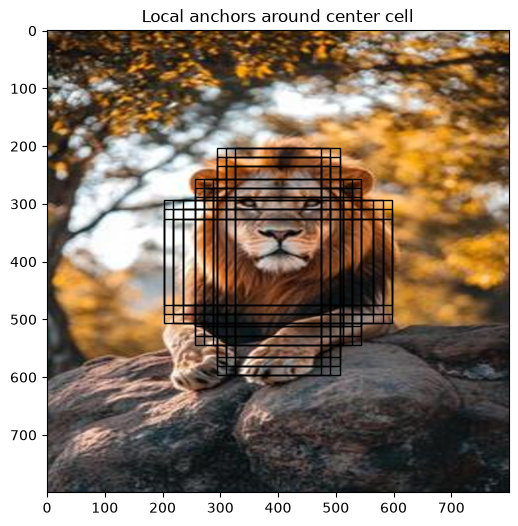

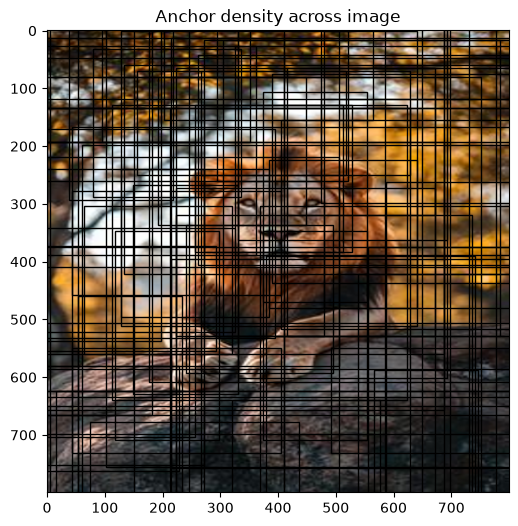

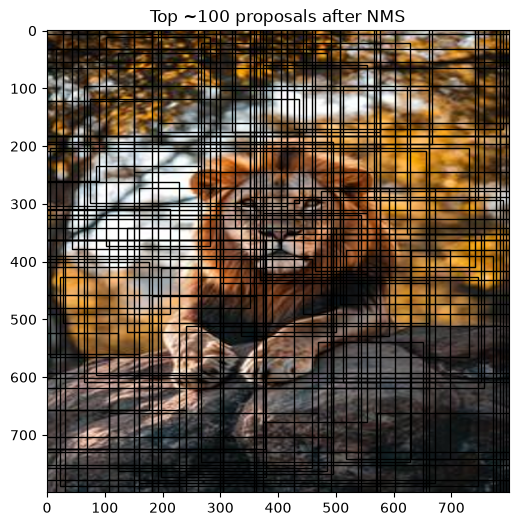

In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.ops import nms

def generate_anchors(base_size=32, ratios=(0.5, 1.0, 2.0), scales=(8, 16, 32)):
    anchors = []
    for s in scales:
        area = (base_size * s) ** 2
        for r in ratios:
            w = np.sqrt(area / r)
            h = w * r
            anchors.append([-w / 2, -h / 2, w / 2, h / 2])
    return np.array(anchors, dtype=np.float32)

def shift_anchors(feat_h, feat_w, stride, base_anchors):
    shifts_x = np.arange(0, feat_w) * stride
    shifts_y = np.arange(0, feat_h) * stride
    shift_x, shift_y = np.meshgrid(shifts_x, shifts_y)
    shifts = np.stack([shift_x.ravel(), shift_y.ravel(),
                       shift_x.ravel(), shift_y.ravel()], axis=1)
    A = base_anchors.shape[0]
    K = shifts.shape[0]
    all_anchors = (base_anchors.reshape((1, A, 4))
                   + shifts.reshape((K, 1, 4))).reshape(-1, 4)
    return all_anchors

base_anchors = generate_anchors()
all_anchors = shift_anchors(50, 50, 16, base_anchors)
print("Anchors:", all_anchors.shape)

center = (25, 25)
idxs = []
for dy in range(-1, 2):
    for dx in range(-1, 2):
        y = (center[0] + dy) * 16
        x = (center[1] + dx) * 16
        start = ((center[0] + dy) * 50 + (center[1] + dx)) * base_anchors.shape[0]
        idxs.extend([start, start + 1, start + 2])

possible_dirs = [
    "/content/images",
    "../assets/images",
    "./assets/images",
    os.path.join(os.getcwd(), "assets/images"),
    os.path.join(os.getcwd(), "Lab04_two_stages/assets/images"),
]
image_dir = next((d for d in possible_dirs if os.path.exists(d) and any(f.lower().endswith((".png", ".jpg", ".jpeg")) for f in os.listdir(d))), None)
img_names = sorted([f for f in os.listdir(image_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
img_path = os.path.join(image_dir, img_names[0])

img = Image.open(img_path).convert("RGB")
img = img.resize((800, 800))

plt.figure(figsize=(6, 6))
plt.imshow(img)
ax = plt.gca()
for i in idxs:
    x1, y1, x2, y2 = all_anchors[i]
    rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=1)
    ax.add_patch(rect)
plt.title("Local anchors around center cell")
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(img)
ax = plt.gca()
for i in np.random.choice(len(all_anchors), 100, replace=False):
    x1, y1, x2, y2 = all_anchors[i]
    rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=1)
    ax.add_patch(rect)
plt.title("Anchor density across image")
plt.show()

boxes_tensor = torch.from_numpy(all_anchors).float()
scores = torch.rand(len(all_anchors), dtype=torch.float32)
keep = nms(boxes_tensor, scores, iou_threshold=0.7)
keep_100 = keep[:100]

plt.figure(figsize=(6, 6))
plt.imshow(img)
ax = plt.gca()
for i in keep_100:
    x1, y1, x2, y2 = all_anchors[i.item()]
    rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=1)
    ax.add_patch(rect)
plt.title("Top ~100 proposals after NMS")
plt.show()


**Nhận xét**

Với ảnh đầu vào kích thước (800, 800) và feature map kích thước 50x50 (stride 16), tại mỗi vị trí ta sinh ra 9 anchor boxes tương ứng với 3 scale và 3 aspect ratio khác nhau. Khi trượt trên toàn bộ ảnh, tổng số lượng anchor thu được lên tới 22,500 boxes phủ kín không gian ảnh nhằm bao quát mọi kích thước và hình dạng vật thể.

Tuy nhiên mật độ anchor quá dày đặc dẫn đến phần lớn là vùng nền và các box bị trùng lặp nhiều quanh cùng một đối tượng. Việc áp dụng NMS sơ bộ giúp loại bỏ các box chồng lấn có IoU cao và chỉ giữ lại khoảng 100 proposals tiềm năng nhất, giảm đáng kể độ phức tạp tính toán cho các bước tiếp theo.


## 3.3 RoI Pool vs RoI Align – cắt/gộp đặc trưng chính xác phân số


Spatial scale: 0.0625
RoI Pool shape: (2, 1024, 7, 7)
RoI Align shape: (2, 1024, 7, 7)
Mean absolute difference: 1.1749948263168335

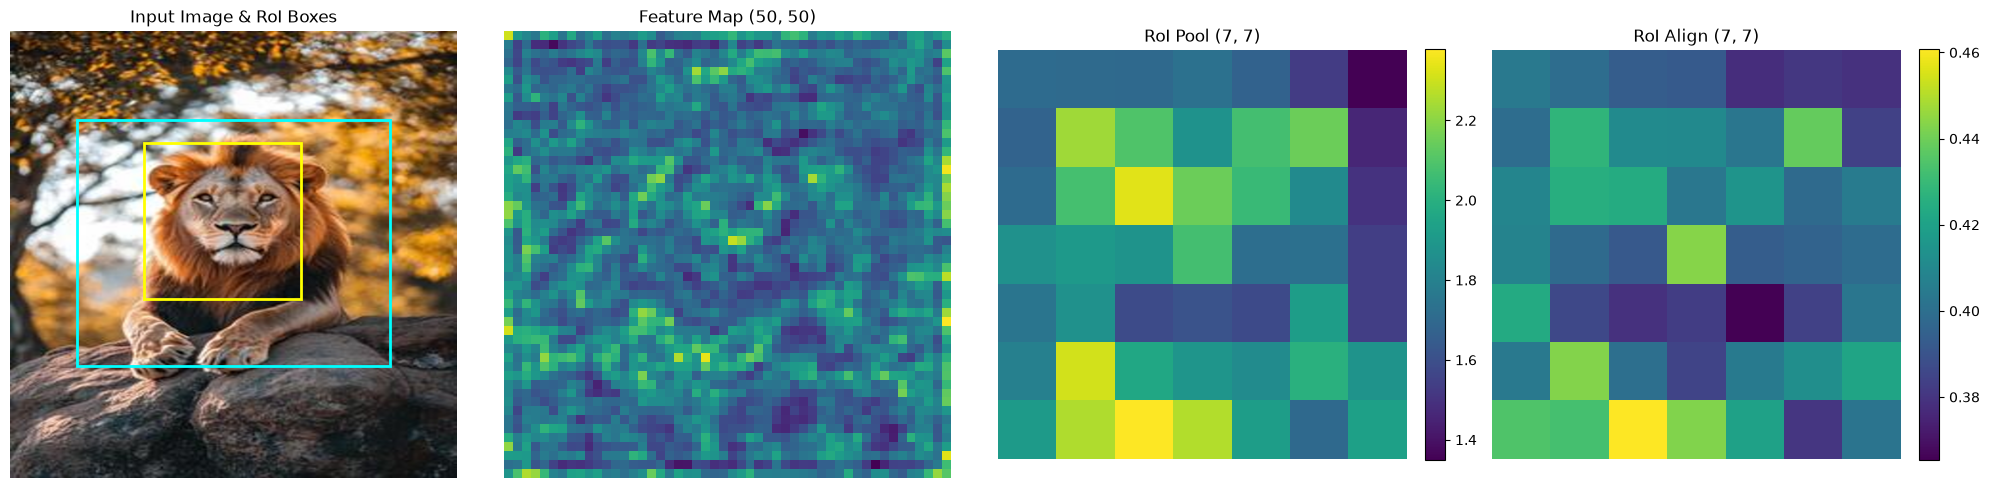

In [3]:
import os
import torch
import torchvision
from torchvision.ops import roi_align, roi_pool
from torchvision.models.feature_extraction import create_feature_extractor
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

possible_dirs = [
    "/content/images",
    "../assets/images",
    "./assets/images",
    os.path.join(os.getcwd(), "assets/images"),
    os.path.join(os.getcwd(), "Lab04_two_stages/assets/images"),
]
image_dir = next((d for d in possible_dirs if os.path.exists(d) and any(f.lower().endswith((".png", ".jpg", ".jpeg")) for f in os.listdir(d))), None)
img_names = sorted([f for f in os.listdir(image_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
img_path = os.path.join(image_dir, img_names[0])
img = Image.open(img_path).convert("RGB")

target_size = (800, 800)
img_resized = img.resize(target_size)

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
x = transform(img_resized).unsqueeze(0).to(device)

backbone = torchvision.models.resnet50(weights="IMAGENET1K_V2").to(device).eval()
nodes = {"layer3": "C4"}
extractor = create_feature_extractor(backbone, return_nodes=nodes).to(device).eval()

with torch.no_grad():
    feat = extractor(x)["C4"]

spatial_scale = feat.shape[-1] / target_size[0]

boxes_img = torch.tensor([
    [target_size[0] * 0.15, target_size[1] * 0.20, target_size[0] * 0.85, target_size[1] * 0.75],
    [target_size[0] * 0.30, target_size[1] * 0.25, target_size[0] * 0.65, target_size[1] * 0.60]
], dtype=torch.float32, device=device)

rois = torch.cat([torch.zeros((boxes_img.size(0), 1), device=device), boxes_img], dim=1)

pooled_pool = roi_pool(feat, rois, output_size=(7, 7), spatial_scale=spatial_scale)
pooled_align = roi_align(feat, rois, output_size=(7, 7), spatial_scale=spatial_scale, aligned=True)

print("Spatial scale:", spatial_scale)
print("RoI Pool shape:", tuple(pooled_pool.shape))
print("RoI Align shape:", tuple(pooled_align.shape))
diff = torch.abs(pooled_align - pooled_pool).mean().item()
print("Mean absolute difference:", diff)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_resized)
for i, box in enumerate(boxes_img.cpu().numpy()):
    w, h = box[2] - box[0], box[3] - box[1]
    color = "cyan" if i == 0 else "yellow"
    rect = patches.Rectangle((box[0], box[1]), w, h, fill=False, edgecolor=color, linewidth=2)
    axes[0].add_patch(rect)
axes[0].set_title("Input Image & RoI Boxes")
axes[0].axis("off")

fmap_full = feat[0].mean(dim=0).detach().cpu().numpy()
axes[1].imshow(fmap_full, interpolation="nearest", cmap="viridis")
axes[1].set_title(f"Feature Map {tuple(feat.shape[-2:])}")
axes[1].axis("off")

pool_map = pooled_pool[0].mean(dim=0).detach().cpu().numpy()
im_pool = axes[2].imshow(pool_map, interpolation="nearest", cmap="viridis")
axes[2].set_title(f"RoI Pool {tuple(pooled_pool.shape[-2:])}")
axes[2].axis("off")
plt.colorbar(im_pool, ax=axes[2], fraction=0.046, pad=0.04)

align_map = pooled_align[0].mean(dim=0).detach().cpu().numpy()
im_align = axes[3].imshow(align_map, interpolation="nearest", cmap="viridis")
axes[3].set_title(f"RoI Align {tuple(pooled_align.shape[-2:])}")
axes[3].axis("off")
plt.colorbar(im_align, ax=axes[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

if device.type == "cuda":
    torch.cuda.empty_cache()


**Nhận xét**

Các vùng RoI từ ảnh gốc được chuẩn hóa đưa về cùng kích thước đặc trưng cố định (7, 7) để làm đầu vào cho các tầng fully-connected ở Stage 2. Tỷ lệ không gian spatial_scale được tính tự động từ tỷ số giữa kích thước feature map và kích thước ảnh đầu vào thay vì gán giá trị cố định.

So sánh giữa hai phương pháp cho thấy RoI Pool sử dụng phép làm tròn tọa độ (lượng tử hóa) nên làm mất mát thông tin vị trí các pixel và gây lệch đặc trưng, đặc biệt là với các vật thể nhỏ. Ngược lại, RoI Align áp dụng nội suy song tuyến (bilinear interpolation) tại các tọa độ phân số liên tục, giúp bảo toàn thông tin không gian chính xác hơn và cho ra biểu diễn đặc trưng mượt mà hơn.


## 3.4 NMS – Non-Maximum Suppression (lọc chồng lấn)


Total candidate boxes: 16
IoU threshold = 0.3: kept 2 boxes -> indices: [6, 13]
IoU threshold = 0.5: kept 3 boxes -> indices: [6, 13, 2]
IoU threshold = 0.7: kept 8 boxes -> indices: [6, 13, 14, 10, 3, 8, 15, 0]

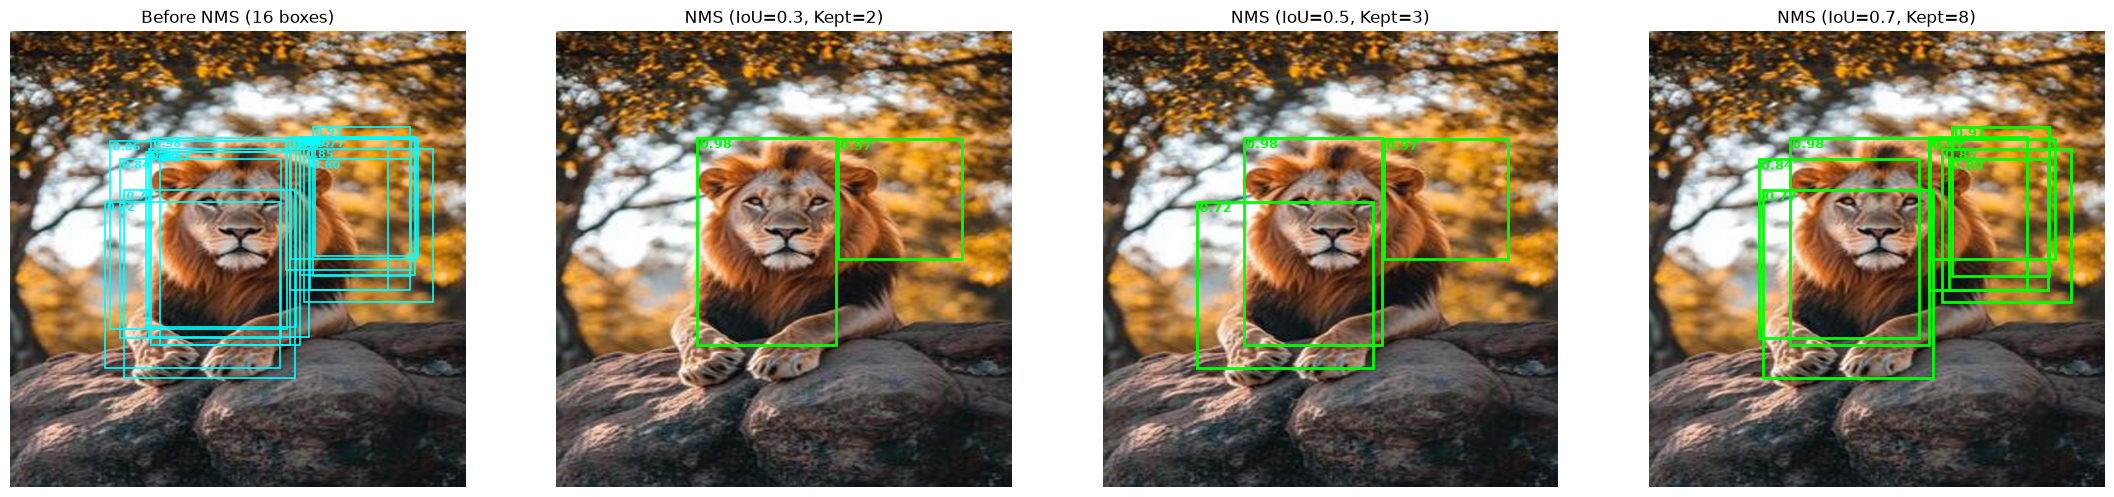

In [4]:
import os
import torch
import torchvision
from torchvision.ops import nms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

possible_dirs = [
    "/content/images",
    "../assets/images",
    "./assets/images",
    os.path.join(os.getcwd(), "assets/images"),
    os.path.join(os.getcwd(), "Lab04_two_stages/assets/images"),
]
image_dir = next((d for d in possible_dirs if os.path.exists(d) and any(f.lower().endswith((".png", ".jpg", ".jpeg")) for f in os.listdir(d))), None)
img_names = sorted([f for f in os.listdir(image_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
img_path = os.path.join(image_dir, img_names[0])
img = Image.open(img_path).convert("RGB")
target_size = (800, 800)
img_resized = img.resize(target_size)
w_img, h_img = target_size

np.random.seed(42)
torch.manual_seed(42)

cluster_centers = [
    (w_img * 0.45, h_img * 0.50, w_img * 0.35, h_img * 0.40),
    (w_img * 0.75, h_img * 0.40, w_img * 0.25, h_img * 0.30),
]

generated_boxes = []
generated_scores = []

for cx, cy, bw, bh in cluster_centers:
    for _ in range(8):
        offset_x = np.random.uniform(-0.15, 0.15) * bw
        offset_y = np.random.uniform(-0.15, 0.15) * bh
        scale_w = np.random.uniform(0.85, 1.15) * bw
        scale_h = np.random.uniform(0.85, 1.15) * bh

        x1 = max(0, cx + offset_x - scale_w / 2)
        y1 = max(0, cy + offset_y - scale_h / 2)
        x2 = min(w_img, cx + offset_x + scale_w / 2)
        y2 = min(h_img, cy + offset_y + scale_h / 2)

        dist = np.sqrt(offset_x**2 + offset_y**2) / (bw + 1e-5)
        score = float(np.clip(1.0 - dist + np.random.uniform(-0.1, 0.1), 0.3, 0.98))

        generated_boxes.append([x1, y1, x2, y2])
        generated_scores.append(score)

boxes = torch.tensor(generated_boxes, dtype=torch.float32, device=device)
scores = torch.tensor(generated_scores, dtype=torch.float32, device=device)

print("Total candidate boxes:", len(boxes))

thresholds = [0.3, 0.5, 0.7]
for thresh in thresholds:
    keep = nms(boxes, scores, iou_threshold=thresh)
    print(f"IoU threshold = {thresh}: kept {len(keep)} boxes -> indices: {keep.cpu().tolist()}")

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(img_resized)
for box, sc in zip(boxes.cpu().numpy(), scores.cpu().numpy()):
    w, h = box[2] - box[0], box[3] - box[1]
    rect = patches.Rectangle((box[0], box[1]), w, h, fill=False, edgecolor="cyan", linewidth=1.2)
    axes[0].add_patch(rect)
    axes[0].text(box[0] + 4, box[1] + 16, f"{sc:.2f}", color="cyan", fontsize=8, weight="bold")
axes[0].set_title(f"Before NMS ({len(boxes)} boxes)")
axes[0].axis("off")

for idx, thresh in enumerate(thresholds):
    ax = axes[idx + 1]
    ax.imshow(img_resized)
    keep = nms(boxes, scores, iou_threshold=thresh).cpu().numpy()
    for k in keep:
        box = boxes[k].cpu().numpy()
        sc = scores[k].item()
        w, h = box[2] - box[0], box[3] - box[1]
        rect = patches.Rectangle((box[0], box[1]), w, h, fill=False, edgecolor="lime", linewidth=2)
        ax.add_patch(rect)
        ax.text(box[0] + 4, box[1] + 18, f"{sc:.2f}", color="lime", fontsize=9, weight="bold")
    ax.set_title(f"NMS (IoU={thresh}, Kept={len(keep)})")
    ax.axis("off")

plt.tight_layout()
plt.show()

if device.type == "cuda":
    torch.cuda.empty_cache()


**Nhận xét**

Thuật toán NMS (Non-Maximum Suppression) hoạt động bằng cách sắp xếp các bounding box theo điểm tin cậy (score) giảm dần, sau đó lần lượt giữ lại box có điểm cao nhất và loại bỏ các box lân cận có mức độ trùng lấn (IoU) vượt quá ngưỡng quy định.

Kết quả thử nghiệm với các ngưỡng IoU khác nhau cho thấy:
- Ngưỡng IoU thấp (0.3): Quá trình lọc diễn ra nghiêm ngặt, loại bỏ phần lớn các box xung quanh và chỉ giữ lại 2 box tốt nhất đại diện cho 2 cụm đối tượng, nhưng có nguy cơ lọc nhầm nếu hai vật thể đứng quá sát nhau.
- Ngưỡng IoU cao (0.7): Quá trình lọc nới lỏng hơn, giữ lại nhiều box (8 boxes) nên vẫn còn hiện tượng chồng chéo quanh cùng một vật thể.
- Ngưỡng IoU trung bình (0.5): Cân bằng tốt giữa việc giữ lại đủ các đối tượng độc lập và khử sạch các box dư thừa.
